In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
from torch.utils.data import DataLoader
from PIL import Image


In [2]:
train = '/kaggle/input/fer2013/train'
test = '/kaggle/input/fer2013/test'
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229,0.224, 0.225])
])
train_dataset = ImageFolder(root=train,transform=transform)
test_dataset = ImageFolder(root=test,transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


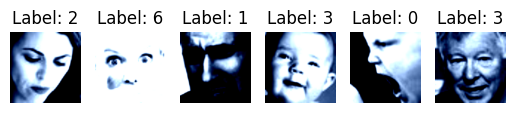

In [3]:
def show_images(dataloader):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(nrows=1, ncols=6)
    for idx in range(6):
        ax = axes[idx]
        img = images[idx].permute(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f"Label: {labels[idx].item()}")
        ax.axis('off')
    plt.show()

show_images(train_loader)

In [4]:
model = models.resnet50(pretrained=True)
for param in model.layer4.parameters():
    param.requires_grad = True
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 7)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),  lr=0.001, momentum= 0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [7]:
def Train(model, train_loader, criterion, optimizer, scheduler, epochs, device):
    model = model.to(device)
    
    for epoch in range(epochs):
        running_loss = 0.0
        model.train()  
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
            epoch_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")
        
        scheduler.step(epoch_loss)

    print("Обучение завершено.")


In [8]:
Train(model, train_loader, criterion, optimizer,scheduler, 70, device)

Epoch [1/70], Loss: 1.2439
Epoch [2/70], Loss: 0.9064
Epoch [3/70], Loss: 0.6940
Epoch [4/70], Loss: 0.5002
Epoch [5/70], Loss: 0.3408
Epoch [6/70], Loss: 0.2504
Epoch [7/70], Loss: 0.1987
Epoch [8/70], Loss: 0.1401
Epoch [9/70], Loss: 0.1180
Epoch [10/70], Loss: 0.0924
Epoch [11/70], Loss: 0.0850
Epoch [12/70], Loss: 0.0799
Epoch [13/70], Loss: 0.0663
Epoch [14/70], Loss: 0.0497
Epoch [15/70], Loss: 0.0398
Epoch [16/70], Loss: 0.0519
Epoch [17/70], Loss: 0.0702
Epoch [18/70], Loss: 0.0390
Epoch [19/70], Loss: 0.0346
Epoch [20/70], Loss: 0.0270
Epoch [21/70], Loss: 0.0320
Epoch [22/70], Loss: 0.0196
Epoch [23/70], Loss: 0.0145
Epoch [24/70], Loss: 0.0113
Epoch [25/70], Loss: 0.0084
Epoch [26/70], Loss: 0.0069
Epoch [27/70], Loss: 0.0078
Epoch [28/70], Loss: 0.0077
Epoch [29/70], Loss: 0.0062
Epoch [30/70], Loss: 0.0058
Epoch [31/70], Loss: 0.0059
Epoch [32/70], Loss: 0.0054
Epoch [33/70], Loss: 0.0064
Epoch [34/70], Loss: 0.0119
Epoch [35/70], Loss: 0.0096
Epoch [36/70], Loss: 0.0087
E

In [9]:
def test(model, test_loader):
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Accuracy: {100* correct / total}%")


test(model, test_loader)

Accuracy: 99.83628827197046%


In [10]:
classes = ['angry', 'disgust', 'fear', 'happy',
           'neutral', 'sad', 'surprise']

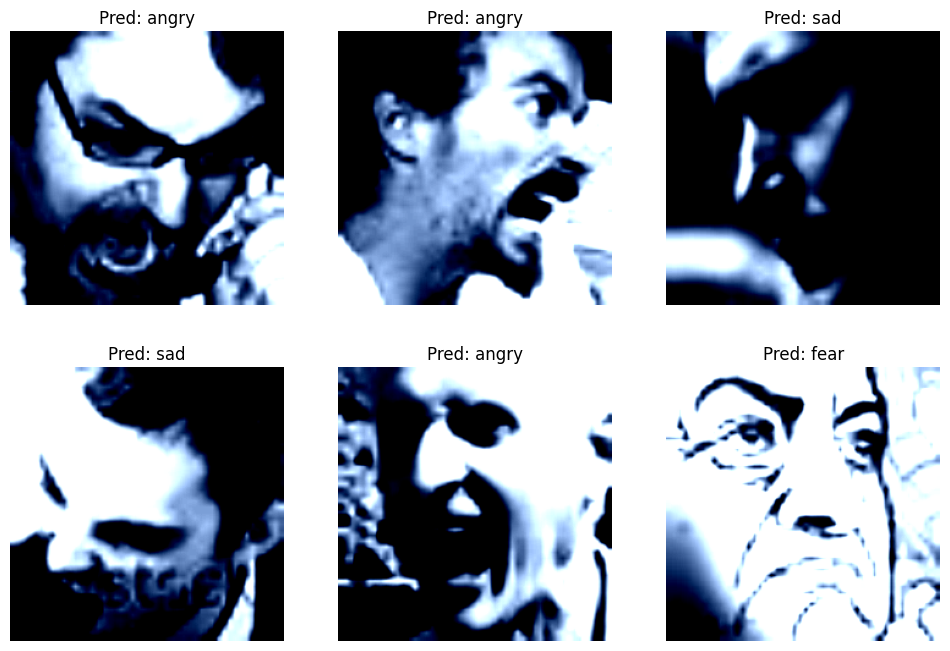

In [11]:
def show_predictions(model, test_loader, classes, device):
    model.eval()  
    images, labels = next(iter(test_loader)) 
    images = images.to(device)
    with torch.no_grad():  
        outputs = model(images)
    _, preds = torch.max(outputs, 1)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    for idx in range(6):
        ax = axes[idx]
        ax.imshow(images[idx].permute(1, 2, 0).cpu().numpy())
        ax.set_title(f"Pred: {classes[preds[idx].item()]}")
        ax.axis('off')
    plt.show()

show_predictions(model, test_loader, classes, device)

In [12]:
torch.save(model.state_dict(), 'model_weights.pth')
